# Steam Games Exploratory Analysis

I’m using the cleaned Parquet file in this notebook to look for patterns in the Steam games data. I’m checking release dates, pricing, reviews, ownership estimates, genres, tags, categories, and platform support.

The goal is to describe what is in the dataset and compare groups carefully. These results show associations, not proof that one thing causes another.

Why: This gives me a first set of findings that can help answer the project questions while keeping the limits of the dataset visible.

In [86]:
from pathlib import Path
import json
import pandas as pd

## Load the cleaned dataset

The first cells load the cleaned Parquet file from notebook 2. The nested fields were stored as JSON text during export, so I’m turning them back into lists and dictionaries before analyzing them.

Why: The analysis needs the nested fields in their original structure so that genres, tags, developers, and categories can be counted correctly.

In [87]:
processed_path = Path("../data/processed/steam_games_clean.parquet")

games = pd.read_parquet(processed_path)

nested_columns = [
    "developers",
    "publishers",
    "genres",
    "categories",
    "tags",
]

def parse_nested(value):
    if value is None or value is pd.NA:
        return pd.NA

    if not isinstance(value, (str, list, dict)) and pd.isna(value):
        return pd.NA

    if isinstance(value, str):
        value = json.loads(value)

    if isinstance(value, dict):
        return {
            key: votes
            for key, votes in value.items()
            if votes is not None and pd.notna(votes)
        }

    return value


for column in nested_columns:
    games[column] = games[column].map(parse_nested)

print("Shape:", games.shape)
games.head()

Shape: (141900, 66)


,AppID,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,peak_ccu_available,peak_ccu_analysis,average_playtime_forever_available,average_playtime_forever_analysis,average_playtime_2weeks_available,average_playtime_2weeks_analysis,median_playtime_forever_available,median_playtime_forever_analysis,median_playtime_2weeks_available,median_playtime_2weeks_analysis
0,2539430,Black Dragon Mage Playtest,2023-08-01,0,0.00,0,<NA>,<NA>,<NA>,<NA>,...,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN
1,496350,Supipara - Chapter 1 Spring Has Come!,2016-07-29,0,5.24,0,"Springtime, April: when the cherry trees come ...","Springtime, April: when the cherry trees come ...","Spring has come, and our protagonist, Yukinari...",<NA>,...,False,NaN,True,8.0,False,NaN,True,8.0,False,NaN
2,1034400,Mystery Solitaire The Black Raven,2019-05-06,0,4.99,0,"Immerse yourself in the most beloved, mystical...","Immerse yourself in the most beloved, mystical...",Discover an entrancing and spectacular world!,<NA>,...,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN
3,3292190,버튜버 파라노이아 - Vtuber Paranoia,2024-10-31,0,8.99,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...","synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",Yuha! I'll start the broadcast! Hakko's extrem...,<NA>,...,True,1.0,False,NaN,False,NaN,False,NaN,False,NaN
4,3631080,Maze Quest VR,2025-04-24,0,4.99,0,Its not just a Maze; its a Quest! Enter the ca...,Its not just a Maze; its a Quest! Enter the ca...,Its not just a Maze; its a Quest! Enter the ca...,<NA>,...,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN


## Review the cleaned analysis fields

Before making comparisons, I’m checking the data types, missing values, and number of unique values for the fields I plan to use. This helps me remember which measures are available for most games and which ones are sparse.

Why: A result based on a field that is missing for most games needs more caution than a result based on a field that is widely available.

In [88]:
core_columns = [
    "release_year",
    "price",
    "is_free",
    "owners_midpoint",
    "review_count",
    "positive_ratio",
    "user_score_analysis",
    "metacritic_score_analysis",
    "peak_ccu_analysis",
    "average_playtime_forever_analysis",
    "windows",
    "mac",
    "linux",
]

analysis_profile = pd.DataFrame({
    "dtype": games[core_columns].dtypes.astype(str),
    "missing_pct": games[core_columns].isna().mean().mul(100).round(2),
    "unique_values": games[core_columns].nunique(dropna=True),
})

analysis_profile

,dtype,missing_pct,unique_values
release_year,int32,0.00,30
price,float64,0.00,1096
is_free,bool,0.00,2
owners_midpoint,Float64,0.00,14
review_count,int64,0.00,5910
positive_ratio,float64,41.52,17971
user_score_analysis,float64,99.97,30
metacritic_score_analysis,float64,96.99,72
peak_ccu_analysis,float64,86.12,1109
average_playtime_forever_analysis,float64,81.49,3036


## Look at release years and dates

I’m checking how many games appear for each release year and whether any records have a release date after today. The next cells separate historical games from upcoming games so the main comparisons use released games.

Why: Release-year counts show how the catalog is distributed over time, while separating upcoming games prevents future records from being treated like games that have already had a chance to collect reviews or players.

In [89]:
release_year_profile = (
    games["release_year"]
    .value_counts()
    .sort_index()
    .rename("game_count")
    .to_frame()
)

print("Earliest year:", games["release_year"].min())
print("Latest year:", games["release_year"].max())

release_year_profile

Earliest year: 1997
Latest year: 2026


,game_count
release_year,
1997,2
1998,1
1999,2
2000,2
2001,4
2002,1
2003,3
2004,6
2005,7


In [90]:
today = pd.Timestamp.today().normalize()

future_release_dates = games[
    games["release_date"] > today
].copy()

print("Current date:", today.date())
print("Future-dated records:", len(future_release_dates))

future_release_dates[
    ["AppID", "name", "release_date"]
].head(10)

Current date: 2026-09-18
Future-dated records: 2


,AppID,name,release_date
125386,4418940,Roten,2026-12-01
127928,3635790,Terminal Insanity: CodeJacker,2026-09-30


In [91]:
historical_games = games[
    games["release_date"] <= today
].copy()

upcoming_games = games[
    games["release_date"] > today
].copy()

print("Historical/released games:", len(historical_games))
print("Upcoming games:", len(upcoming_games))

Historical/released games: 141898
Upcoming games: 2


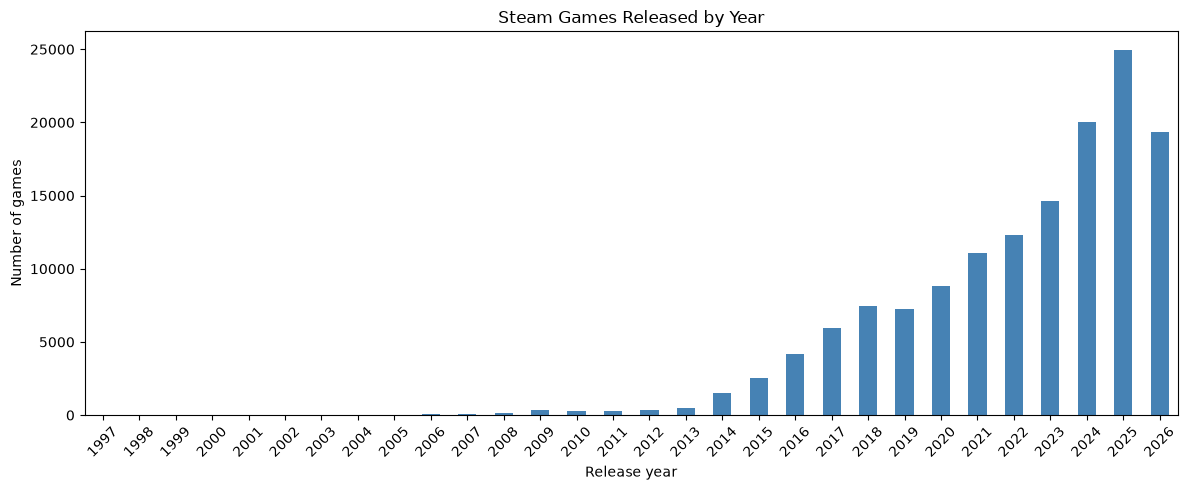

In [92]:
import matplotlib.pyplot as plt

release_counts = (
    historical_games
    .groupby("release_year")
    .size()
    .rename("game_count")
)

ax = release_counts.plot(
    kind="bar",
    figsize=(12, 5),
    color="steelblue",
)

ax.set_title("Steam Games Released by Year")
ax.set_xlabel("Release year")
ax.set_ylabel("Number of games")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Compare free and paid games

I’m first checking how many games are free or paid. Then I’m looking at the price distribution for paid games and comparing engagement between the two groups. A zero value does not always mean no activity, so I’m using the availability fields from notebook 2 when needed.

Why: Pricing is one of the main questions in this project. The price distribution also helps me notice unusual listings without automatically treating high prices as data errors.

In [93]:
free_paid_summary = (
    historical_games["is_free"]
    .map({True: "Free", False: "Paid"})
    .value_counts()
    .rename_axis("pricing_type")
    .rename("game_count")
    .to_frame()
)

free_paid_summary["percentage"] = (
    free_paid_summary["game_count"]
    / free_paid_summary["game_count"].sum()
    * 100
).round(2)

free_paid_summary

,game_count,percentage
pricing_type,,
Paid,113323,79.86
Free,28575,20.14


In [94]:
paid_games = historical_games[
    ~historical_games["is_free"]
].copy()

paid_price_summary = (
    paid_games["price"]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .round(2)
)

paid_price_summary

count    113323.00
mean          6.24
std          13.64
min           0.49
25%           1.79
50%           3.99
75%           7.49
90%          12.49
95%          16.99
99%          34.99
max         999.99
Name: price, dtype: float64

In [95]:
expensive_games = (
    paid_games
    .nlargest(10, "price")
    [["AppID", "name", "price", "release_date"]]
)

expensive_games

,AppID,name,price,release_date
132594,4693030,Congratulations On Your Purchase,999.99,2026-05-28
41088,2504210,The Leverage Game Business Edition,999.98,2023-08-26
68275,2499620,The Leverage Game,999.98,2023-08-25
34463,1200520,Ascent Free-Roaming VR Experience,999.00,2019-12-27
31935,3013840,True Love,500.00,2024-06-27
77652,1105450,Aartform Curvy 3D 4.0,299.99,2020-01-20
85479,253670,Aartform Curvy 3D 3.0,299.90,2013-11-12
102212,502570,Houdini Indie,269.99,2018-10-10
331,2023640,Hidden Industries Top-Down 3D,199.99,2022-06-18
2035,3190870,Knights Shadow,199.99,2024-09-24


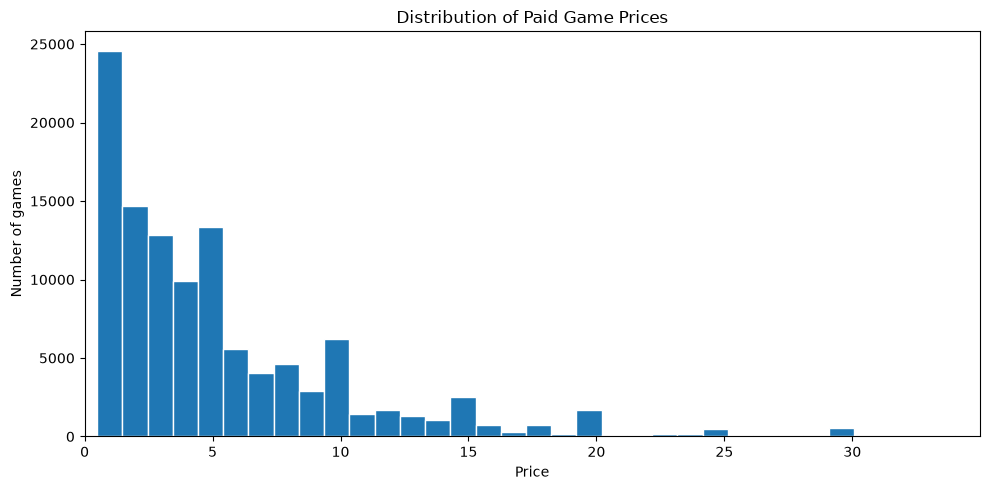

Plot includes prices up to the 99th percentile: $34.99


In [96]:
price_plot_limit = paid_games["price"].quantile(0.99)

prices_for_plot = paid_games.loc[
    paid_games["price"] <= price_plot_limit,
    "price",
]

plt.figure(figsize=(10, 5))

plt.hist(
    prices_for_plot,
    bins=35,
    edgecolor="white",
)

plt.title("Distribution of Paid Game Prices")
plt.xlabel("Price")
plt.ylabel("Number of games")
plt.xlim(0, price_plot_limit)
plt.tight_layout()
plt.show()

print(f"Plot includes prices up to the 99th percentile: ${price_plot_limit:.2f}")

## Explore reviews and estimated owners

Review counts and owner estimates are very uneven. I’m checking their distributions and using a log transformation for the charts so the smaller values are easier to see alongside the very popular games.

Why: Without the log transformation, a few extremely popular games would dominate the chart and hide most of the catalog. The transformed charts show shape and relative differences, not raw counts directly.

In [97]:
review_profile = (
    historical_games["review_count"]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .round(2)
)

games_with_reviews_pct = (
    historical_games["review_count"].gt(0).mean() * 100
)

print(f"Games with at least one review: {games_with_reviews_pct:.2f}%")
review_profile

Games with at least one review: 58.48%


count     141898.00
mean        1049.41
std        30340.65
min            0.00
25%            0.00
50%            3.00
75%           35.00
90%          282.00
95%         1036.00
99%        13108.15
max      8815087.00
Name: review_count, dtype: float64

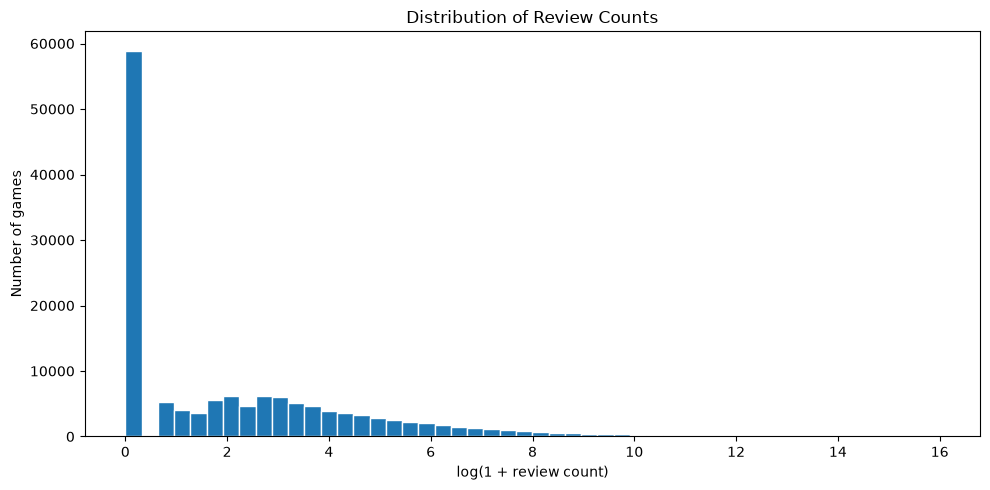

In [98]:
import numpy as np

review_count_log = np.log1p(
    historical_games["review_count"]
)

plt.figure(figsize=(10, 5))

plt.hist(
    review_count_log,
    bins=50,
    edgecolor="white",
)

plt.title("Distribution of Review Counts")
plt.xlabel("log(1 + review count)")
plt.ylabel("Number of games")
plt.tight_layout()
plt.show()

In [99]:
owner_profile = (
    historical_games["owners_midpoint"]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .round(2)
)

owner_profile

count       141898.0
mean        74225.54
std       1199188.07
min              0.0
25%              0.0
50%          10000.0
75%          10000.0
90%          35000.0
95%         150000.0
99%         750000.0
max      150000000.0
Name: owners_midpoint, dtype: Float64

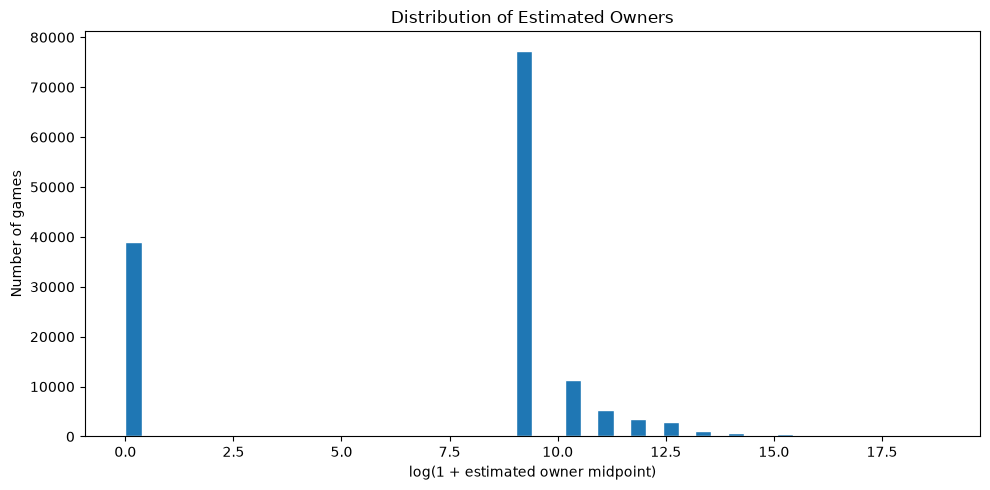

In [100]:
owners_log = np.log1p(
    historical_games["owners_midpoint"]
)

plt.figure(figsize=(10, 5))

plt.hist(
    owners_log,
    bins=50,
    edgecolor="white",
)

plt.title("Distribution of Estimated Owners")
plt.xlabel("log(1 + estimated owner midpoint)")
plt.ylabel("Number of games")
plt.tight_layout()
plt.show()

## Compare engagement between free and paid games

I’m comparing reviews, estimated owners, and peak CCU between free and paid games. I’m also making a fairer comparison that ignores zero values when they represent unavailable information.

Why: Looking only at raw medians could make a group seem less engaged simply because unavailable values were recorded as zero. The availability-aware comparison gives a more reasonable view, although the groups can still differ in many other ways.

In [101]:
free_paid_engagement = (
    historical_games
    .groupby("is_free", observed=True)
    .agg(
        game_count=("AppID", "count"),
        median_owners=("owners_midpoint", "median"),
        median_reviews=("review_count", "median"),
        median_peak_ccu=("peak_ccu_analysis", "median"),
        pct_with_reviews=(
            "review_count",
            lambda values: values.gt(0).mean() * 100,
        ),
    )
    .rename(index={False: "Paid", True: "Free"})
    .round(2)
)

free_paid_engagement

,game_count,median_owners,median_reviews,median_peak_ccu,pct_with_reviews
is_free,,,,,
Paid,113323,10000.0,5.0,3.0,65.73
Free,28575,0.0,0.0,3.0,29.72


In [102]:
fair_comparison = (
    historical_games
    .assign(
        owners_observed=historical_games["owners_midpoint"].where(
            historical_games["owners_midpoint"] > 0
        ),
        reviews_observed=historical_games["review_count"].where(
            historical_games["review_count"] > 0
        ),
    )
    .groupby("is_free", observed=True)
    .agg(
        game_count=("AppID", "count"),
        pct_with_owner_estimate=(
            "owners_observed",
            lambda values: values.notna().mean() * 100,
        ),
        median_owners_when_available=(
            "owners_observed",
            "median",
        ),
        pct_with_reviews=(
            "reviews_observed",
            lambda values: values.notna().mean() * 100,
        ),
        median_reviews_when_available=(
            "reviews_observed",
            "median",
        ),
        median_peak_ccu=("peak_ccu_analysis", "median"),
    )
    .rename(index={False: "Paid", True: "Free"})
    .round(2)
)

fair_comparison

,game_count,pct_with_owner_estimate,median_owners_when_available,pct_with_reviews,median_reviews_when_available,median_peak_ccu
is_free,,,,,,
Paid,113323,82.0,10000.0,65.73,21.0,3.0
Free,28575,34.93,10000.0,29.72,45.0,3.0


In [103]:
reviewed_games = historical_games[
    historical_games["review_count"] > 0
].copy()

review_quality_by_price = (
    reviewed_games
    .groupby("is_free", observed=True)
    .agg(
        reviewed_game_count=("AppID", "count"),
        median_positive_percent=(
            "positive_ratio",
            lambda values: values.median() * 100,
        ),
        median_review_count=("review_count", "median"),
    )
    .rename(index={False: "Paid", True: "Free"})
    .round(2)
)

review_quality_by_price

,reviewed_game_count,median_positive_percent,median_review_count
is_free,,,
Paid,74489,82.41,21.0
Free,8493,78.57,45.0


## Examine genres

Games can have more than one genre, so I’m counting each genre assignment separately. The next cells show the most common genres and compare review activity among genres with enough games to be useful.

Why: This helps show what types of games are common and whether review activity differs across genres. Genre percentages can add up to more than 100 percent because one game can have several genres.

In [104]:
genre_counts = (
    historical_games[["AppID", "genres"]]
    .explode("genres")
    .dropna(subset=["genres"])
    .groupby("genres")["AppID"]
    .nunique()
    .sort_values(ascending=False)
    .head(20)
    .rename("game_count")
    .to_frame()
)

genre_counts

,game_count
genres,
Indie,94379
Casual,59627
Action,52651
Adventure,51396
Simulation,29132
Strategy,26860
RPG,24427
Free To Play,14498
Early Access,13943


In [105]:
genre_counts["percentage_of_games"] = (
    genre_counts["game_count"]
    / historical_games["AppID"].nunique()
    * 100
).round(2)

genre_counts

,game_count,percentage_of_games
genres,,
Indie,94379,66.51
Casual,59627,42.02
Action,52651,37.10
Adventure,51396,36.22
Simulation,29132,20.53
Strategy,26860,18.93
RPG,24427,17.21
Free To Play,14498,10.22
Early Access,13943,9.83


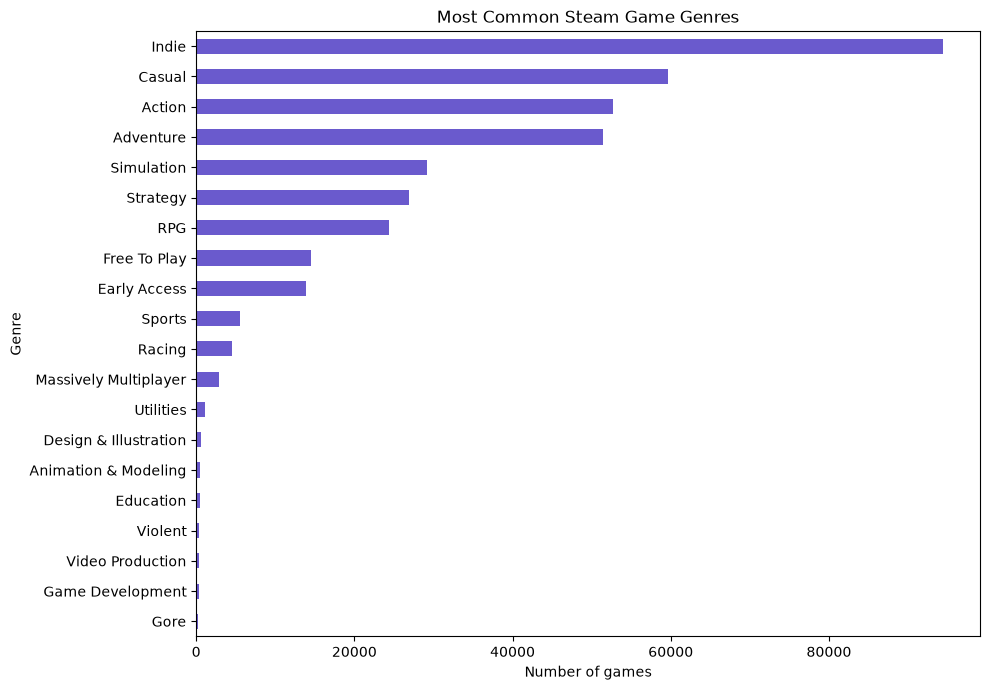

In [106]:
genre_plot = genre_counts.sort_values("game_count")

ax = genre_plot["game_count"].plot(
    kind="barh",
    figsize=(10, 7),
    color="slateblue",
)

ax.set_title("Most Common Steam Game Genres")
ax.set_xlabel("Number of games")
ax.set_ylabel("Genre")
plt.tight_layout()
plt.show()

In [107]:
genre_engagement = (
    historical_games[
        ["AppID", "genres", "review_count", "positive_ratio"]
    ]
    .explode("genres")
    .dropna(subset=["genres"])
    .groupby("genres")
    .agg(
        game_count=("AppID", "nunique"),
        pct_with_reviews=(
            "review_count",
            lambda values: values.gt(0).mean() * 100,
        ),
        median_reviews_when_available=(
            "review_count",
            lambda values: values[values > 0].median(),
        ),
        median_positive_percent=(
            "positive_ratio",
            lambda values: values.median() * 100,
        ),
    )
    .query("game_count >= 100")
    .sort_values("median_reviews_when_available", ascending=False)
    .head(20)
    .round(2)
)

genre_engagement

,game_count,pct_with_reviews,median_reviews_when_available,median_positive_percent
genres,,,,
Massively Multiplayer,2890,59.07,73.0,66.67
Free To Play,14498,32.84,69.0,78.57
Web Publishing,114,78.07,65.0,76.37
RPG,24427,61.85,36.0,80.00
Simulation,29132,58.44,33.0,76.92
Adventure,51396,65.56,27.0,81.39
Strategy,26860,62.44,27.0,79.77
Gore,257,97.28,26.5,57.73
Animation & Modeling,488,77.46,24.0,76.28


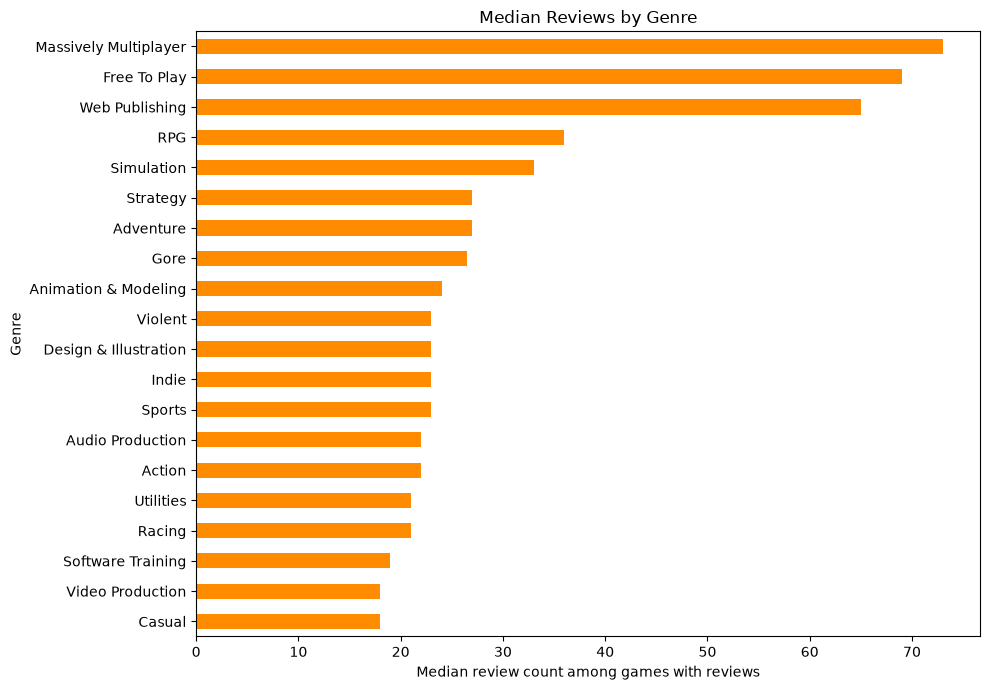

In [108]:
genre_engagement_plot = genre_engagement.sort_values(
    "median_reviews_when_available"
)

ax = genre_engagement_plot[
    "median_reviews_when_available"
].plot(
    kind="barh",
    figsize=(10, 7),
    color="darkorange",
)

ax.set_title("Median Reviews by Genre")
ax.set_xlabel("Median review count among games with reviews")
ax.set_ylabel("Genre")
plt.tight_layout()
plt.show()

## Examine tags

Tags are another multi-value field. I’m counting how many games have each tag. The values in the tag dictionary are vote counts, but here I’m focusing on whether a tag is attached to a game.

Why: Tags can show common themes and play styles that may not be captured by the broader genre labels. I’m counting game coverage here, not treating tag vote totals as ratings.

In [109]:
tag_table = (
    historical_games[["AppID", "tags"]]
    .dropna(subset=["tags"])
    .assign(
        tag=lambda frame: frame["tags"].map(
            lambda tags: list(tags.keys())
        )
    )
    .explode("tag")
    .dropna(subset=["tag"])
)

tag_counts = (
    tag_table
    .groupby("tag")["AppID"]
    .nunique()
    .sort_values(ascending=False)
    .head(20)
    .rename("game_count")
    .to_frame()
)

tag_counts

,game_count
tag,
Singleplayer,50369
Indie,48568
Action,36825
Casual,36570
Adventure,35213
2D,26800
3D,18004
Simulation,17900
Strategy,17859


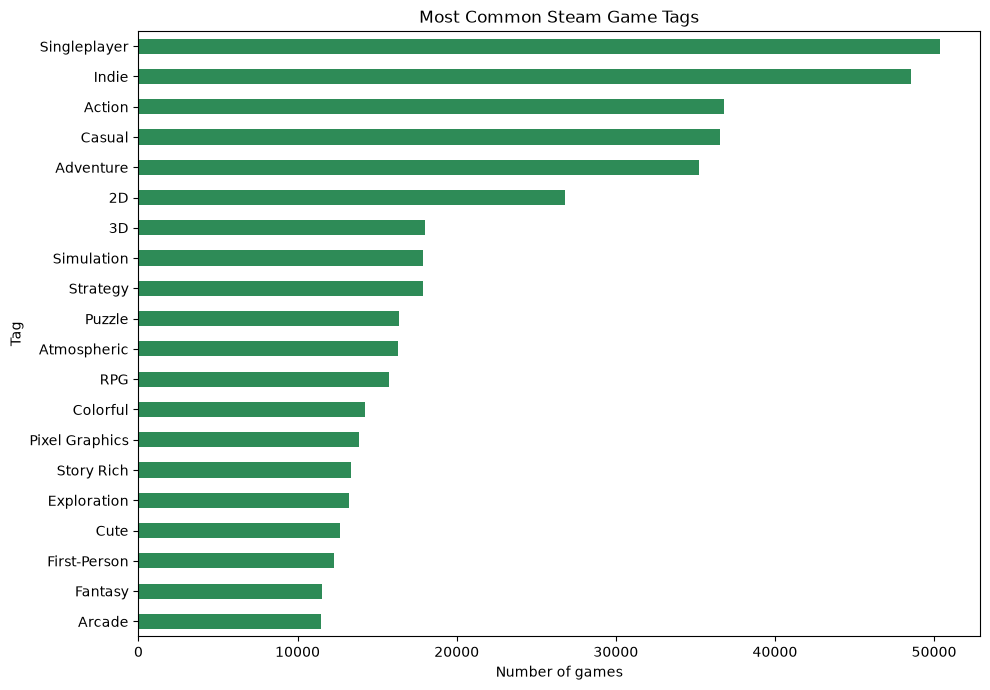

In [110]:
tag_plot = tag_counts.sort_values("game_count")

ax = tag_plot["game_count"].plot(
    kind="barh",
    figsize=(10, 7),
    color="seagreen",
)

ax.set_title("Most Common Steam Game Tags")
ax.set_xlabel("Number of games")
ax.set_ylabel("Tag")
plt.tight_layout()
plt.show()

## Examine platform support

I’m checking how many games support Windows, Mac, and Linux. Since a game can support more than one platform, the platform percentages will not add up to 100 percent.

Why: Platform support helps describe who can access the games in the catalog. The result measures listed support, not actual player demand on each platform.

In [111]:
platform_summary = (
    historical_games[["windows", "mac", "linux"]]
    .sum()
    .rename("game_count")
    .to_frame()
)

platform_summary["percentage"] = (
    platform_summary["game_count"]
    / len(historical_games)
    * 100
).round(2)

platform_summary

,game_count,percentage
windows,141836,99.96
mac,24062,16.96
linux,18208,12.83


In [112]:
platform_columns = ["windows", "mac", "linux"]

platform_labels = historical_games[platform_columns].apply(
    lambda row: " + ".join(
        platform.title()
        for platform, supported in row.items()
        if supported
    ) or "None",
    axis=1,
)

platform_combinations = (
    platform_labels
    .value_counts()
    .rename_axis("platform_support")
    .rename("game_count")
    .to_frame()
)

platform_combinations["percentage"] = (
    platform_combinations["game_count"]
    / len(historical_games)
    * 100
).round(2)

platform_combinations

,game_count,percentage
platform_support,,
Windows,112366,79.19
Windows + Mac + Linux,12742,8.98
Windows + Mac,11281,7.95
Windows + Linux,5447,3.84
Mac,37,0.03
Linux,17,0.01
None,6,0.00
Mac + Linux,2,0.00


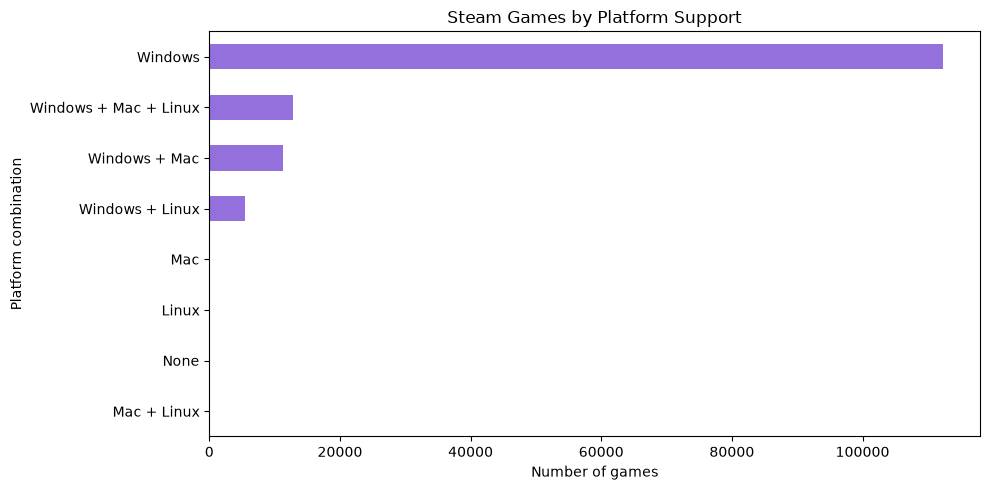

In [113]:
platform_plot = platform_combinations.sort_values("game_count")

ax = platform_plot["game_count"].plot(
    kind="barh",
    figsize=(10, 5),
    color="mediumpurple",
)

ax.set_title("Steam Games by Platform Support")
ax.set_xlabel("Number of games")
ax.set_ylabel("Platform combination")

plt.tight_layout()
plt.show()

## Compare price bands and engagement

Instead of comparing every exact price, I’m grouping games into price bands. This makes it easier to compare review availability, reviews, owners, peak CCU, and playtime without letting individual prices dominate the results.

Why: Price bands make broad patterns easier to see, but they also hide differences between games inside the same band. The results should be read as group comparisons rather than evidence that price causes engagement.

In [114]:
price_analysis = historical_games.copy()

price_analysis["price_band"] = pd.cut(
    price_analysis["price"],
    bins=[-0.01, 0, 5, 10, 20, 50, float("inf")],
    labels=[
        "Free",
        "$0.01-$5",
        "$5-$10",
        "$10-$20",
        "$20-$50",
        "$50+",
    ],
)

price_band_summary = (
    price_analysis
    .groupby("price_band", observed=False)
    .agg(
        game_count=("AppID", "count"),
        pct_with_reviews=(
            "review_count",
            lambda values: values.gt(0).mean() * 100,
        ),
        median_reviews_when_available=(
            "review_count",
            lambda values: values[values > 0].median(),
        ),
        median_owners_when_available=(
            "owners_midpoint",
            lambda values: values[values > 0].median(),
        ),
        median_peak_ccu=("peak_ccu_analysis", "median"),
        median_playtime=("average_playtime_forever_analysis", "median"),
    )
    .round(2)
)

price_band_summary

,game_count,pct_with_reviews,median_reviews_when_available,median_owners_when_available,median_peak_ccu,median_playtime
price_band,,,,,,
Free,28575,29.72,45.0,10000.0,3.0,147.0
$0.01-$5,74200,69.23,18.0,10000.0,2.0,194.0
$5-$10,24395,59.08,28.0,10000.0,4.0,250.0
$10-$20,11741,59.65,59.0,10000.0,6.0,354.5
$20-$50,2301,58.63,97.0,10000.0,18.0,767.0
$50+,686,51.75,13.0,10000.0,11.0,1258.0


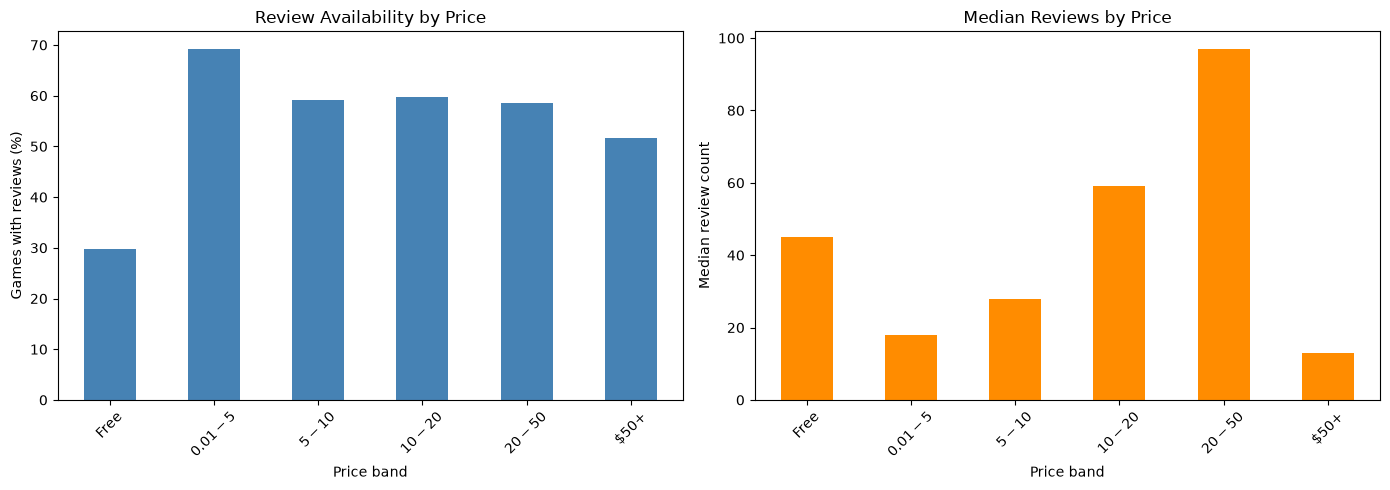

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

price_band_summary["pct_with_reviews"].plot(
    kind="bar",
    ax=axes[0],
    color="steelblue",
)

axes[0].set_title("Review Availability by Price")
axes[0].set_xlabel("Price band")
axes[0].set_ylabel("Games with reviews (%)")
axes[0].tick_params(axis="x", rotation=45)

price_band_summary["median_reviews_when_available"].plot(
    kind="bar",
    ax=axes[1],
    color="darkorange",
)

axes[1].set_title("Median Reviews by Price")
axes[1].set_xlabel("Price band")
axes[1].set_ylabel("Median review count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Identify highly reviewed games

I’m listing the games with the most reviews to see which titles have the largest amount of review activity. This is a popularity measure, not a list of the objectively best games.

Why: Review volume helps identify highly visible games and provides examples for the later within-genre and within-year comparisons. Older or long-running games may have had more time to collect reviews.

In [116]:
top_reviewed_games = (
    historical_games[
        [
            "AppID",
            "name",
            "release_date",
            "price",
            "genres",
            "review_count",
            "positive_ratio",
            "owners_midpoint",
            "peak_ccu_analysis",
        ]
    ]
    .sort_values("review_count", ascending=False)
    .head(20)
    .copy()
)

top_reviewed_games["positive_percent"] = (
    top_reviewed_games["positive_ratio"] * 100
).round(2)

top_reviewed_games[
    [
        "AppID",
        "name",
        "release_date",
        "price",
        "genres",
        "review_count",
        "positive_percent",
        "owners_midpoint",
        "peak_ccu_analysis",
    ]
]

,AppID,name,release_date,price,genres,review_count,positive_percent,owners_midpoint,peak_ccu_analysis
45509,730,Counter-Strike 2,2012-08-21,0.00,"[Action, Free To Play]",8815087,86.69,150000000.0,1013936.0
8878,578080,PUBG: BATTLEGROUNDS,2017-12-21,0.00,"[Action, Adventure, Massively Multiplayer, Fre...",2557944,59.44,150000000.0,314682.0
4193,570,Dota 2,2013-07-09,0.00,"[Action, Strategy, Free To Play]",2498969,81.52,150000000.0,623941.0
59122,271590,Grand Theft Auto V Legacy,2015-04-13,0.00,"[Action, Adventure]",1990556,87.41,75000000.0,67851.0
10927,105600,Terraria,2011-05-16,4.99,"[Action, Adventure, Indie, RPG]",1409473,97.48,35000000.0,24580.0
40969,359550,Tom Clancy's Rainbow Six® Siege X,2015-12-01,0.00,"[Action, Free To Play]",1398584,83.86,35000000.0,51847.0
5377,252490,Rust,2018-02-08,19.99,"[Action, Adventure, Indie, Massively Multiplay...",1227784,87.24,35000000.0,143870.0
57377,440,Team Fortress 2,2007-10-10,0.00,"[Action, Free To Play]",1161472,89.91,75000000.0,43819.0
35440,4000,Garry's Mod,2006-11-29,4.99,"[Casual, Indie, Simulation]",1159707,96.80,35000000.0,18400.0
44134,2358720,Black Myth: Wukong,2024-08-19,59.99,"[Action, Adventure, RPG]",1150098,96.66,75000000.0,15004.0


In [117]:
reviewed_games = historical_games[
    historical_games["review_count"] > 0
].copy()

high_review_threshold = reviewed_games["review_count"].quantile(0.95)

reviewed_games["review_group"] = np.where(
    reviewed_games["review_count"] >= high_review_threshold,
    "Top 5% by reviews",
    "Other reviewed games",
)

high_review_profile = (
    reviewed_games
    .groupby("review_group", observed=True)
    .agg(
        game_count=("AppID", "count"),
        median_review_count=("review_count", "median"),
        median_positive_percent=(
            "positive_ratio",
            lambda values: values.median() * 100,
        ),
        pct_free=(
            "is_free",
            lambda values: values.mean() * 100,
        ),
        median_owners_when_available=(
            "owners_midpoint",
            lambda values: values[values > 0].median(),
        ),
        median_peak_ccu=("peak_ccu_analysis", "median"),
        median_playtime=("average_playtime_forever_analysis", "median"),
    )
    .round(2)
)

print(f"Top 5% review threshold: {high_review_threshold:.0f}")
high_review_profile

Top 5% review threshold: 2657


,game_count,median_review_count,median_positive_percent,pct_free,median_owners_when_available,median_peak_ccu,median_playtime
review_group,,,,,,,
Other reviewed games,78831,21.0,81.25,9.99,10000.0,2.0,186.0
Top 5% by reviews,4151,7531.0,87.92,14.86,750000.0,59.0,679.0


## Find games that stand out within their group

Overall review counts favor large and well-known games. I’m also ranking games within their own genre and release year to find titles that perform unusually well compared with similar games.

Why: Relative rankings are a fairer way to find standouts than using one overall list. A percentile of 1 means the game is at the top of the observed group, not that it is objectively the best game.

In [118]:
genre_review_data = (
    historical_games[
        ["AppID", "name", "genres", "review_count", "positive_ratio"]
    ]
    .explode("genres")
    .dropna(subset=["genres"])
)

genre_review_data = genre_review_data[
    genre_review_data["review_count"] > 0
].copy()

genre_sizes = (
    genre_review_data
    .groupby("genres")["AppID"]
    .nunique()
)

valid_genres = genre_sizes[genre_sizes >= 100].index

genre_review_data = genre_review_data[
    genre_review_data["genres"].isin(valid_genres)
].copy()

genre_review_data["genre_review_percentile"] = (
    genre_review_data
    .groupby("genres")["review_count"]
    .rank(pct=True)
)

top_genre_performers = (
    genre_review_data[
        genre_review_data["genre_review_percentile"] >= 0.99
    ]
    .sort_values(
        ["genre_review_percentile", "review_count"],
        ascending=False,
    )
    .head(30)
)

top_genre_performers

,AppID,name,genres,review_count,positive_ratio,genre_review_percentile
45509,730,Counter-Strike 2,Action,8815087,0.866932,1.000000
45509,730,Counter-Strike 2,Free To Play,8815087,0.866932,1.000000
8878,578080,PUBG: BATTLEGROUNDS,Adventure,2557944,0.594406,1.000000
8878,578080,PUBG: BATTLEGROUNDS,Massively Multiplayer,2557944,0.594406,1.000000
4193,570,Dota 2,Strategy,2498969,0.815193,1.000000
10927,105600,Terraria,Indie,1409473,0.974818,1.000000
10927,105600,Terraria,RPG,1409473,0.974818,1.000000
35440,4000,Garry's Mod,Casual,1159707,0.967957,1.000000
35440,4000,Garry's Mod,Simulation,1159707,0.967957,1.000000
86168,431960,Wallpaper Engine,Animation & Modeling,894458,0.980368,1.000000


In [119]:
year_review_data = (
    historical_games[
        [
            "AppID",
            "name",
            "release_year",
            "review_count",
            "positive_ratio",
        ]
    ]
    .loc[lambda frame: frame["review_count"] > 0]
    .copy()
)

year_sizes = (
    year_review_data
    .groupby("release_year")["AppID"]
    .nunique()
)

valid_years = year_sizes[year_sizes >= 100].index

year_review_data = year_review_data[
    year_review_data["release_year"].isin(valid_years)
].copy()

year_review_data["year_review_percentile"] = (
    year_review_data
    .groupby("release_year")["review_count"]
    .rank(pct=True)
)

top_year_performers = (
    year_review_data[
        year_review_data["year_review_percentile"] >= 0.99
    ]
    .sort_values(
        ["year_review_percentile", "review_count"],
        ascending=False,
    )
    .head(30)
)

top_year_performers

,AppID,name,release_year,review_count,positive_ratio,year_review_percentile
45509,730,Counter-Strike 2,2012,8815087,0.866932,1.000000
8878,578080,PUBG: BATTLEGROUNDS,2017,2557944,0.594406,1.000000
4193,570,Dota 2,2013,2498969,0.815193,1.000000
59122,271590,Grand Theft Auto V Legacy,2015,1990556,0.874118,1.000000
10927,105600,Terraria,2011,1409473,0.974818,1.000000
5377,252490,Rust,2018,1227784,0.872413,1.000000
44134,2358720,Black Myth: Wukong,2024,1150098,0.966631,1.000000
114885,1245620,ELDEN RING,2022,1056677,0.928893,1.000000
54502,1172470,Apex Legends™,2020,994979,0.671424,1.000000
110911,550,Left 4 Dead 2,2009,963983,0.975350,1.000000


## Compare developers and publishers

I’m comparing developers and publishers by catalog size, review availability, typical review count, and positive review percentage. I’m requiring a minimum number of reviewed games so that one unusual title does not decide the result.

Why: This helps compare the types of catalogs associated with different creators or publishers. These fields are not exclusive, and inconsistent capitalization or naming can split one organization into multiple groups, so the normalized version is used for exploration.

In [78]:
def summarize_creators(data, column, minimum_games=20):
    creator_data = (
        data[
            [
                "AppID",
                column,
                "review_count",
                "positive_ratio",
            ]
        ]
        .explode(column)
        .dropna(subset=[column])
    )

    summary = (
        creator_data
        .groupby(column)
        .agg(
            game_count=("AppID", "nunique"),
            pct_with_reviews=(
                "review_count",
                lambda values: values.gt(0).mean() * 100,
            ),
            median_reviews_when_available=(
                "review_count",
                lambda values: values[values > 0].median(),
            ),
            median_positive_percent=(
                "positive_ratio",
                lambda values: values.median() * 100,
            ),
        )
        .query("game_count >= @minimum_games")
        .sort_values("game_count", ascending=False)
        .head(20)
        .round(2)
    )

    return summary


top_developers = summarize_creators(
    historical_games,
    "developers",
)

top_publishers = summarize_creators(
    historical_games,
    "publishers",
)

print("Top developers")
display(top_developers)

print("Top publishers")
display(top_publishers)

Top developers


,game_count,pct_with_reviews,median_reviews_when_available,median_positive_percent
developers,,,,
EroticGamesClub,239,0.00,NaN,NaN
Choice of Games,184,91.85,20.0,79.17
Bully Revenge Studios,164,0.00,NaN,NaN
Boogygames Studios,157,82.17,4.0,68.42
Laush Dmitriy Sergeevich,153,77.78,32.0,76.47
Gamesforgames,151,74.83,23.0,65.00
Cyber Keks,148,0.68,45.0,48.89
Creobit,145,100.00,9.0,60.00
Tero Lunkka,138,75.36,26.0,67.75


Top publishers


,game_count,pct_with_reviews,median_reviews_when_available,median_positive_percent
publishers,,,,
BFG Entertainment,554,91.88,8.0,85.71
PlayWay S.A.,295,44.75,430.0,76.49
8floor,268,99.25,8.0,60.00
EroticGamesClub,239,0.00,NaN,NaN
Kagura Games,218,79.36,174.0,80.00
Strategy First,213,85.92,39.0,61.05
Conglomerate 5,197,100.00,51.0,60.75
HH-Games,196,93.37,17.0,75.00
Hede,188,42.02,22.0,36.00


In [79]:
def summarize_reviewed_creators(
    data,
    column,
    minimum_reviewed_games=20,
):
    creator_data = (
        data[
            [
                "AppID",
                column,
                "review_count",
                "positive_ratio",
            ]
        ]
        .explode(column)
        .dropna(subset=[column])
        .copy()
    )

    creator_data["has_reviews"] = (
        creator_data["review_count"] > 0
    )

    summary = (
        creator_data
        .groupby(column)
        .agg(
            game_count=("AppID", "nunique"),
            reviewed_game_count=("has_reviews", "sum"),
            pct_with_reviews=(
                "has_reviews",
                "mean",
            ),
            median_reviews_when_available=(
                "review_count",
                lambda values: values[values > 0].median(),
            ),
            median_positive_percent=(
                "positive_ratio",
                lambda values: values.median() * 100,
            ),
        )
        .query(
            "reviewed_game_count >= @minimum_reviewed_games"
        )
        .sort_values(
            "median_reviews_when_available",
            ascending=False,
        )
        .head(20)
    )

    summary["pct_with_reviews"] = (
        summary["pct_with_reviews"] * 100
    )

    return summary.round(2)


reviewed_developers = summarize_reviewed_creators(
    historical_games,
    "developers",
)

reviewed_publishers = summarize_reviewed_creators(
    historical_games,
    "publishers",
)

print("Developers with at least 20 reviewed games")
display(reviewed_developers)

print("Publishers with at least 20 reviewed games")
display(reviewed_publishers)

Developers with at least 20 reviewed games


,game_count,reviewed_game_count,pct_with_reviews,median_reviews_when_available,median_positive_percent
developers,,,,,
Valve,36,35,97.22,40659.0,91.39
Feral Interactive (Linux),25,25,100.00,35480.0,85.25
Ubisoft Montreal,36,35,97.22,17734.0,80.92
Feral Interactive (Mac),58,58,100.00,17447.5,75.04
Eidos-Montréal,25,24,96.00,17389.0,72.99
Nixxes,22,22,100.00,17303.5,72.98
Feral interactive (Linux),20,20,100.00,17251.5,72.98
Crystal Dynamics,36,34,94.44,15521.5,72.99
id Software,24,23,95.83,9228.0,87.65


Publishers with at least 20 reviewed games


,game_count,reviewed_game_count,pct_with_reviews,median_reviews_when_available,median_positive_percent
publishers,,,,,
Valve,37,36,97.30,36240.5,92.72
Feral Interactive (Linux),25,25,100.00,35480.0,85.25
PlayStation Publishing LLC,25,22,88.00,27231.5,87.16
Feral Interactive (Mac),57,57,100.00,17444.0,74.53
Feral interactive (Linux),20,20,100.00,17251.5,72.98
Crystal Dynamics,40,37,92.50,15183.0,72.99
Bethesda Softworks,76,69,90.79,14400.0,81.43
Xbox Game Studios,68,57,83.82,12943.0,86.40
"CAPCOM Co., Ltd.",53,39,73.58,9829.0,87.57


In [80]:
def summarize_normalized_creators_fast(
    data,
    column,
    minimum_reviewed_games=20,
):
    creator_data = (
        data[
            [
                "AppID",
                column,
                "review_count",
                "positive_ratio",
            ]
        ]
        .explode(column, ignore_index=True)
        .dropna(subset=[column])
        .copy()
    )

    creator_data["creator_key"] = (
        creator_data[column]
        .astype("string")
        .str.strip()
        .str.casefold()
    )

    creator_data["has_reviews"] = (
        creator_data["review_count"] > 0
    )

    overall_summary = (
        creator_data
        .groupby("creator_key", sort=False)
        .agg(
            game_count=("AppID", "nunique"),
            reviewed_game_count=("has_reviews", "sum"),
            pct_with_reviews=("has_reviews", "mean"),
        )
    )

    reviewed_data = creator_data[
        creator_data["has_reviews"]
    ]

    reviewed_summary = (
        reviewed_data
        .groupby("creator_key", sort=False)
        .agg(
            median_reviews_when_available=(
                "review_count",
                "median",
            ),
            median_positive_percent=(
                "positive_ratio",
                "median",
            ),
        )
    )

    display_names = (
        creator_data
        .groupby("creator_key", sort=False)[column]
        .first()
        .rename("creator_name")
    )

    summary = (
        overall_summary
        .join(reviewed_summary)
        .join(display_names)
        .query(
            "reviewed_game_count >= @minimum_reviewed_games"
        )
    )

    summary["pct_with_reviews"] = (
        summary["pct_with_reviews"] * 100
    )

    return (
        summary
        .set_index("creator_name")
        .sort_values(
            "median_reviews_when_available",
            ascending=False,
        )
        .head(20)
        .round(2)
    )


normalized_developers = summarize_normalized_creators_fast(
    historical_games,
    "developers",
)

normalized_publishers = summarize_normalized_creators_fast(
    historical_games,
    "publishers",
)

print("Normalized developers")
display(normalized_developers)

print("Normalized publishers")
display(normalized_publishers)

Normalized developers


,game_count,reviewed_game_count,pct_with_reviews,median_reviews_when_available,median_positive_percent
creator_name,,,,,
Valve,36,35,97.22,40659.0,0.91
CREATIVE ASSEMBLY,23,21,91.30,25365.0,0.83
Ubisoft Montreal,36,35,97.22,17734.0,0.81
Feral interactive (Linux),45,45,100.00,17566.0,0.73
Feral Interactive (Mac),59,59,100.00,17444.0,0.75
Eidos-Montréal,25,24,96.00,17389.0,0.73
Nixxes,22,22,100.00,17303.5,0.73
Crystal Dynamics,36,34,94.44,15521.5,0.73
id Software,24,23,95.83,9228.0,0.88


Normalized publishers


,game_count,reviewed_game_count,pct_with_reviews,median_reviews_when_available,median_positive_percent
creator_name,,,,,
Valve,37,36,97.30,36240.5,0.93
PlayStation Publishing LLC,25,22,88.00,27231.5,0.87
Feral interactive (Linux),45,45,100.00,17566.0,0.73
Feral Interactive (Mac),59,59,100.00,17444.0,0.75
Crystal Dynamics,40,37,92.50,15183.0,0.73
Bethesda Softworks,76,69,90.79,14400.0,0.81
Xbox Game Studios,68,57,83.82,12943.0,0.86
Warner Bros. Interactive Entertainment,36,33,91.67,9016.0,0.88
"CAPCOM Co., Ltd.",55,41,74.55,8158.0,0.88


## Examine Steam categories

Categories describe features such as single-player, multiplayer, achievements, and controller support. I’m counting the most common categories and then comparing engagement for categories with enough games.

Why: Categories show product features rather than broad genres. Some categories have very few games with reviews, so their median review results should not be treated as stable evidence even when the total category size is large.

In [81]:
category_counts = (
    historical_games[
        ["AppID", "categories"]
    ]
    .explode("categories")
    .dropna(subset=["categories"])
    .groupby("categories")["AppID"]
    .nunique()
    .sort_values(ascending=False)
    .head(20)
    .rename("game_count")
    .to_frame()
)

category_counts["percentage_of_games"] = (
    category_counts["game_count"]
    / historical_games["AppID"].nunique()
    * 100
).round(2)

category_counts

,game_count,percentage_of_games
categories,,
Single-player,126372,89.06
Family Sharing,113776,80.18
Steam Achievements,66074,46.56
Steam Cloud,37145,26.18
Full controller support,29582,20.85
Multi-player,23584,16.62
Partial Controller Support,15022,10.59
Playable without Timed Input,14752,10.40
PvP,14517,10.23


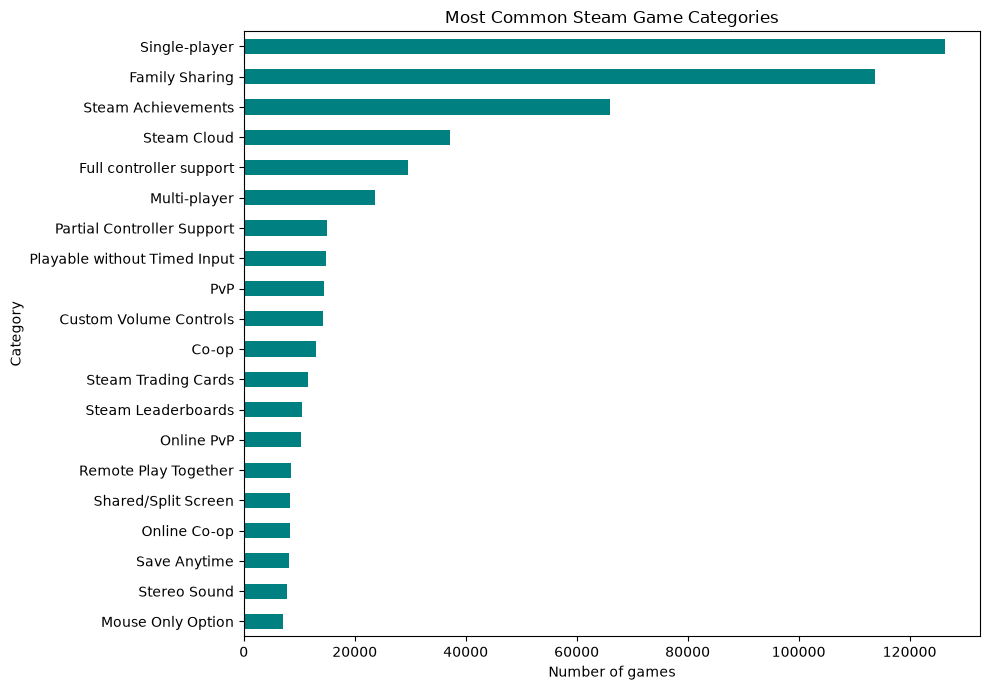

In [82]:
category_plot = category_counts.sort_values("game_count")

ax = category_plot["game_count"].plot(
    kind="barh",
    figsize=(10, 7),
    color="teal",
)

ax.set_title("Most Common Steam Game Categories")
ax.set_xlabel("Number of games")
ax.set_ylabel("Category")

plt.tight_layout()
plt.show()

In [83]:
category_engagement = (
    historical_games[
        [
            "AppID",
            "categories",
            "review_count",
            "positive_ratio",
        ]
    ]
    .explode("categories")
    .dropna(subset=["categories"])
    .groupby("categories")
    .agg(
        game_count=("AppID", "nunique"),
        pct_with_reviews=(
            "review_count",
            lambda values: values.gt(0).mean() * 100,
        ),
        median_reviews_when_available=(
            "review_count",
            lambda values: values[values > 0].median(),
        ),
        median_positive_percent=(
            "positive_ratio",
            lambda values: values.median() * 100,
        ),
    )
    .query("game_count >= 500")
    .sort_values(
        "median_reviews_when_available",
        ascending=False,
    )
    .head(20)
    .round(2)
)

category_engagement

,game_count,pct_with_reviews,median_reviews_when_available,median_positive_percent
categories,,,,
Remote Play on Tablet,1139,85.16,5439.0,89.48
Remote Play on Phone,985,84.06,2791.0,89.67
Surround Sound,1929,21.98,2308.5,85.42
Adjustable Text Size,1644,24.33,652.0,88.28
DualShock Controller Support,1093,0.09,546.0,92.12
Subtitle Options,1420,21.90,425.0,88.86
Remote Play on TV,2738,86.30,381.0,85.70
Steam Trading Cards,11518,92.86,362.0,80.26
In-App Purchases,3522,44.69,305.5,71.02


## Review relationships between numeric measures

The final analysis checks how price, reviews, estimated owners, peak CCU, and playtime move together. I’m using Spearman correlation and log-transformed values because these measures are heavily skewed.

Why: This gives me a compact way to compare several relationships at once. A positive correlation means the measures tend to increase together, but it does not show which measure causes the other or account for every missing or zero value.

In [84]:
relationship_data = historical_games[
    [
        "price",
        "review_count",
        "owners_midpoint",
        "peak_ccu_analysis",
        "average_playtime_forever_analysis",
    ]
].astype("float64")

relationship_data = np.log1p(relationship_data)

relationship_data.columns = [
    "log_price",
    "log_reviews",
    "log_owners",
    "log_peak_ccu",
    "log_playtime",
]

correlation_matrix = (
    relationship_data
    .corr(method="spearman")
    .round(2)
)

correlation_matrix

,log_price,log_reviews,log_owners,log_peak_ccu,log_playtime
log_price,1.00,0.13,0.19,0.20,0.23
log_reviews,0.13,1.00,0.77,0.61,0.43
log_owners,0.19,0.77,1.00,0.54,0.38
log_peak_ccu,0.20,0.61,0.54,1.00,0.55
log_playtime,0.23,0.43,0.38,0.55,1.00


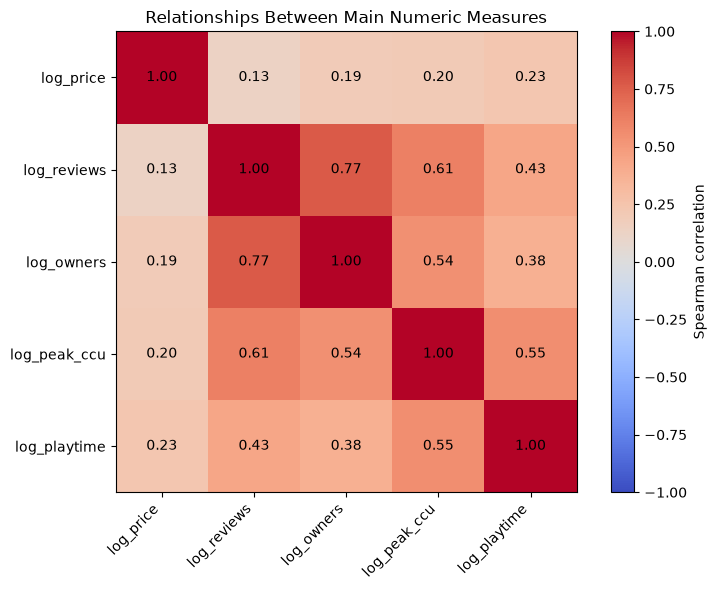

In [85]:
plt.figure(figsize=(8, 6))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)

plt.colorbar(label="Spearman correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right",
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index,
)

for row in range(len(correlation_matrix.index)):
    for column in range(len(correlation_matrix.columns)):
        value = correlation_matrix.iloc[row, column]
        plt.text(
            column,
            row,
            f"{value:.2f}",
            ha="center",
            va="center",
        )

plt.title("Relationships Between Main Numeric Measures")
plt.tight_layout()
plt.show()

## Final exploratory analysis summary

This notebook used the cleaned dataset to look at release patterns, pricing, reviews, estimated owners, genres, tags, categories, platform support, developers, and publishers.

The main patterns I found are:

- Most games in the dataset are paid, although free-to-play games make up a large group.
- Review counts, owner estimates, peak CCU, and playtime are heavily concentrated among a small number of popular games.
- Indie, Casual, Action, and Adventure are the most common genres, but games can have several genres at once.
- Windows support is almost universal, while Mac and Linux support are much less common.
- Games with more reviews generally also have more estimated owners and higher peak CCU.
- Price has only a weak relationship with the other engagement measures in this dataset.

There are still important limitations. Owner counts are ranges, zero values can mean unavailable data, and correlation does not prove causation. The results describe this dataset snapshot rather than the entire Steam market.

I’m treating this notebook as a descriptive exploration. The findings can guide stronger questions for the next stage, but they should not be presented as exact sales estimates, causal conclusions, or a complete picture of Steam.